In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import QTable
from sunpy.time import TimeRange

from hermpy.data import parse_messenger_fips, parse_messenger_mag
from hermpy.net import ClientMESSENGER
from hermpy.plotting import MultiPanel, SpectrogramPanel, TimeseriesPanel

import matplotlib.pyplot as plt
from matplotlib import colormaps as cm
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.colors import Normalize
from PIL import Image

# Download MESSENGER data
Initiate MESSENGER client and define a time range in which you want to download your data from.

In [ ]:
c = ClientMESSENGER()
time_range_1_hour = TimeRange("2011-09-27T12:00", "2011-09-27T13:00")
time_range_2_hour = TimeRange("2011-09-27T12:00", "2011-09-27T14:00")
time_range_8_hour = TimeRange("2011-09-27T12:00", "2011-09-27T20:00")

mag_data = {}

c.query(time_range_1_hour, "MAG")
all_mag_data_1_hour = c.fetch()

c.query(time_range_2_hour, "MAG")
all_mag_data_2_hour = c.fetch()

c.query(time_range_8_hour, "MAG")
all_mag_data_8_hour = c.fetch()

mag_data[0]: QTable = parse_messenger_mag(all_mag_data_1_hour, time_range_1_hour)
mag_data[1]: QTable = parse_messenger_mag(all_mag_data_2_hour, time_range_2_hour)
mag_data[2]: QTable = parse_messenger_mag(all_mag_data_8_hour, time_range_8_hour)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

MAGMSOSCI11270_V08.TAB:   0%|          | 0.00/73.1M [00:00<?, ?B/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Exception ignored in: <function BaseEventLoop.__del__ at 0x7f034d6e2340>
Traceback (most recent call last):
  File "/home/danny/.pyenv/versions/3.13.3/lib/python3.13/asyncio/base_events.py", line 760, in __del__
    self.close()
  File "/home/danny/.pyenv/versions/3.13.3/lib/python3.13/asyncio/unix_events.py", line 73, in close
    self.remove_signal_handler(sig)
  File "/home/danny/.pyenv/versions/3.13.3/lib/python3.13/asyncio/unix_events.py", line 162, in remove_signal_handler
    signal.signal(sig, handler)
  File "/home/danny/.pyenv/versions/3.13.3/lib/python3.13/signal.py", line 58, in signal
    handler = _signal.signal(_enum_to_int(signalnum), _enum_to_int(handler))
ValueError: signal only works in main thread of the main interpreter


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Take magnetic and positional data from time ranges

In [4]:
def total_mag_field(data):
    total_data = data["UTC", "Bx", "By", "Bz"]
    total_mag_data = np.sqrt(total_data["Bx"]**2 + total_data["Bx"]**2 + total_data["Bz"]**2)
    mag_field_data = QTable(data=[data["UTC"], total_mag_data], names=["UTC", "|B|"])
    return total_data, mag_field_data

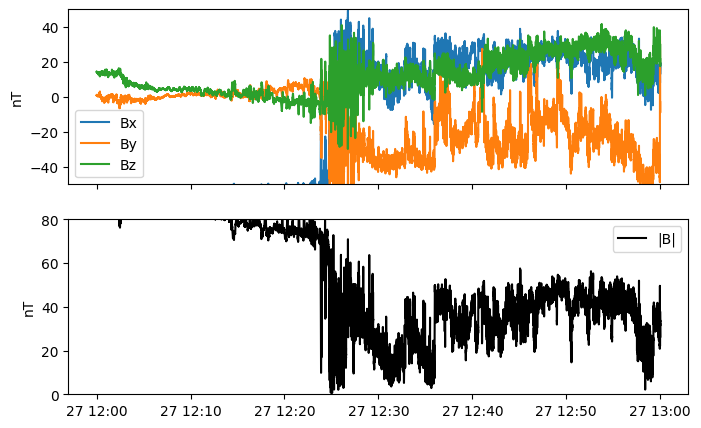

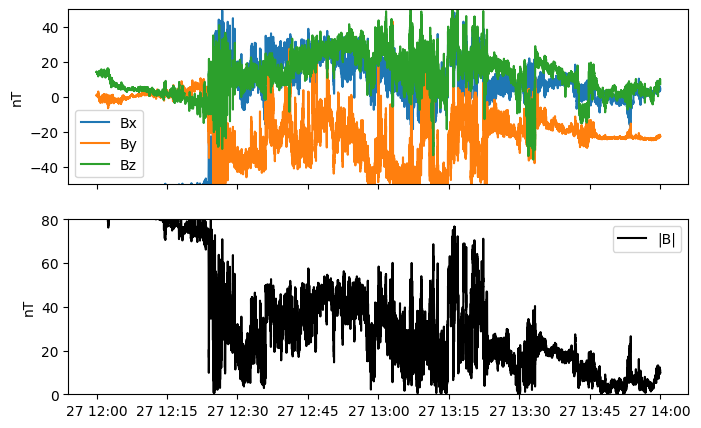

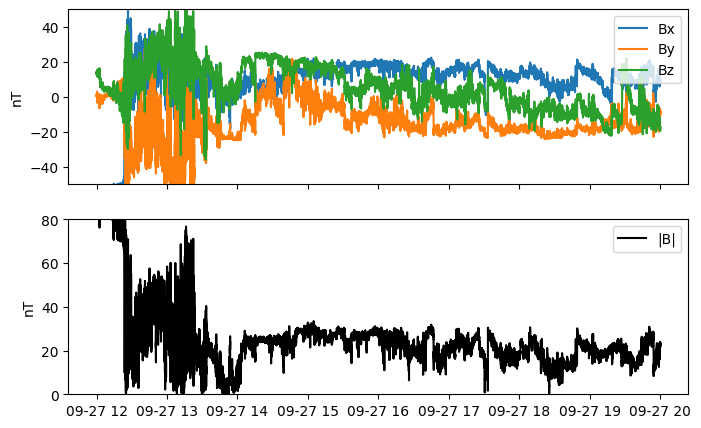

In [ ]:
mag_plotting_data = {}
mag_panels = {}
for i in mag_data:
    mag_plotting_data[i] = total_mag_field(mag_data[i])
    mag_panels[i] = TimeseriesPanel(mag_plotting_data[i][0]) + TimeseriesPanel(mag_plotting_data[i][1])
    fig, ax = mag_panels[i].plot(show=False)
    lines = ax[1].get_lines()
    lines[0].set_color('k')
    ax[1].legend()
    ax[0].set_ylim(-50,50)
    ax[1].set_ylim(0,80)
    plt.show()
    

In [6]:
print(mag_plotting_data[2][0]["UTC"].to_datetime(leap_second_strict="warn"))
print(mag_plotting_data[2][0]["UTC"])

[datetime.datetime(2011, 9, 27, 12, 0, 0, 21000)
 datetime.datetime(2011, 9, 27, 12, 0, 0, 71000)
 datetime.datetime(2011, 9, 27, 12, 0, 0, 121000) ...
 datetime.datetime(2011, 9, 27, 19, 59, 58, 628000)
 datetime.datetime(2011, 9, 27, 19, 59, 59, 128000)
 datetime.datetime(2011, 9, 27, 19, 59, 59, 628000)]
['2011:270:12:00:00.021' '2011:270:12:00:00.071' '2011:270:12:00:00.121'
 ... '2011:270:19:59:58.628' '2011:270:19:59:59.128'
 '2011:270:19:59:59.628']


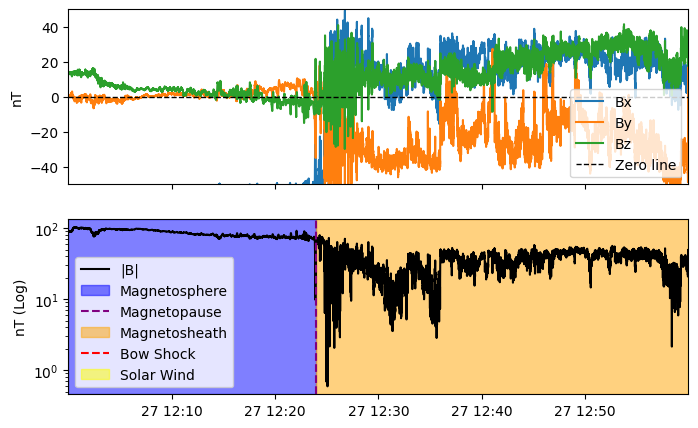

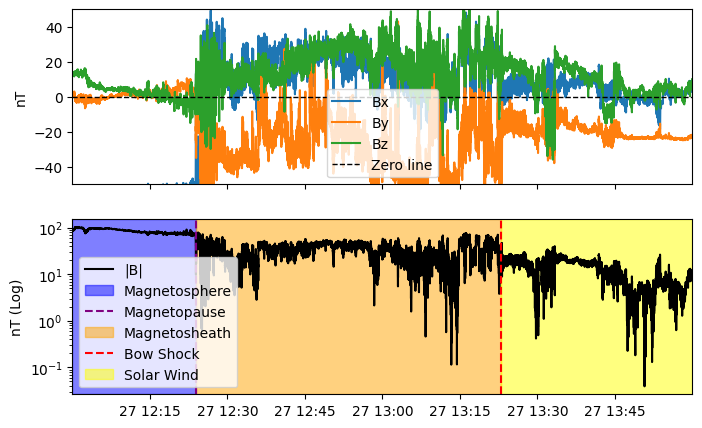

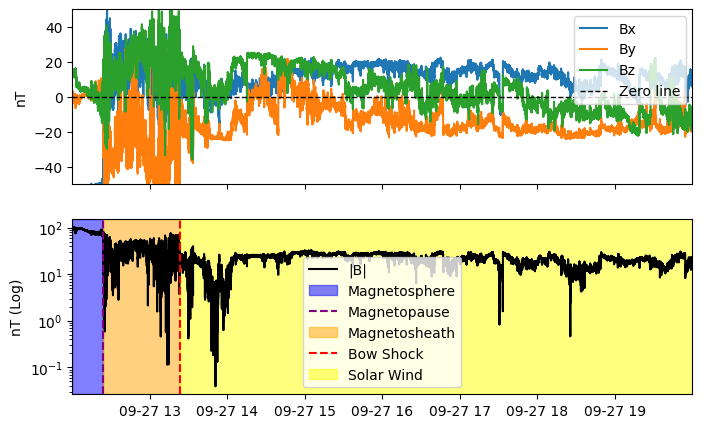

In [ ]:
import datetime as dt

for i in mag_panels:
    xmin = mag_plotting_data[i][0]["UTC"][0].to_datetime()
    xmax = mag_plotting_data[i][0]["UTC"][-1].to_datetime()


    fig, ax = mag_panels[i].plot(show=False)

    lines = ax[1].get_lines()
    lines[0].set_color('k')
    lines = ax[1].get_lines()
    lines[0].set_color('k')


    ax[0].set_ylim(-50,50)
    ax[1].set_yscale("log")
    ax[1].set_ylabel("nT (Log)")

    ax[0].set_xlim(xmin, xmax)
    ax[1].set_xlim(xmin, xmax)

    magnetospheretime1 = dt.datetime(2011, 9, 27, 12, 0, 0, 21000)
    magnetospheretime2 = dt.datetime(2011, 9, 27, 12, 24, 0, 00000)

    ax[0].hlines(0, xmin, xmax, ls='--', lw=1, color='k', label="Zero line")

    ax[1].axvspan(magnetospheretime1, magnetospheretime2, alpha =0.5, color='blue', label='Magnetosphere')
    ax[1].axvline(magnetospheretime2, ls='--', color='purple', label='Magnetopause')
    
    magnetosheathtime = dt.datetime(2011, 9, 27, 13, 23, 0, 21000)
    ax[1].axvspan(magnetospheretime2, magnetosheathtime, alpha =0.5, color='orange', label='Magnetosheath')
    ax[1].axvline(magnetosheathtime, ls='--', color='red', label='Bow Shock')
    
    solarwindtime = mag_plotting_data[i][1]["UTC"][-1].to_datetime(leap_second_strict="warn")

    ax[1].axvspan(magnetosheathtime, solarwindtime, alpha =0.5, color='yellow', label='Solar Wind')

    ax[0].legend()
    ax[1].legend()
    plt.show()

None


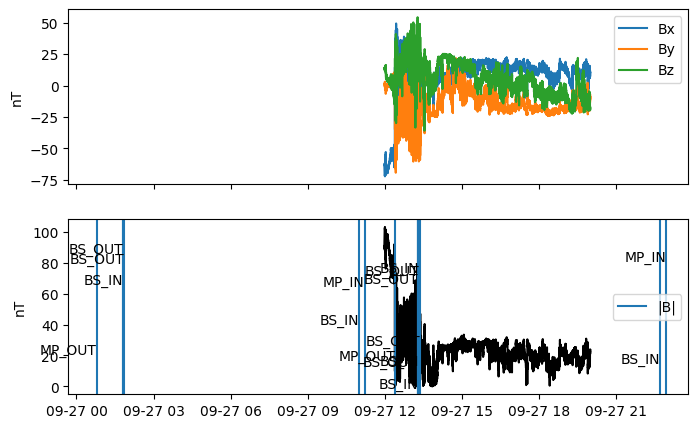

In [ ]:
from astropy.time import Time
import random

model_crossing_list = QTable.read("./data/hollman_2025_crossing_list.csv")

fig, ax = mag_panels[2].plot(show=False)

lines = ax[1].get_lines()
lines[0].set_color('k')
lines = ax[1].get_lines()
lines[0].set_color('k')

data_in_timerange_bool= ["2011-09-27" in t for t in model_crossing_list["Time"]]

true_indices = [i for i in range(len(data_in_timerange_bool)) if data_in_timerange_bool[i]==True]

crossings = model_crossing_list[true_indices]

crossings["Time"] = Time(crossings["Time"])

for cross in crossings:
    ax[1].axvline(cross["Time"].to_datetime())
    ax[1].text(cross["Time"].to_datetime(), random.choice(range(100)), cross["Label"], va='top', ha='right')

print(random.seed())